In [1]:
import torch
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets,transforms
import torch.optim as optim
import torch.nn as nn


In [2]:
transform=transforms.Compose([transforms.ToTensor()])

In [3]:
train_dataset=datasets.MNIST(root='DeepLearning/mnist-original.mat' , download=True, transform =transform)
test_dataset=datasets.MNIST(root='DeepLearning/mnist-original.mat', download=False, transform =transform)

In [4]:
train_dataloader=DataLoader(train_dataset,batch_size=32, shuffle=True)
test_dataloader=DataLoader(test_dataset,batch_size=32,shuffle =False)

In [5]:
class CNN(nn.Module):
    def __init__ (self):
        super(CNN,self).__init__()

        self.conv1=nn.Conv2d(in_channels=1,out_channels=32,kernel_size=3,padding=1)
        self.relu1=nn.ReLU()
        self.pool1=nn.MaxPool2d(kernel_size=2,stride=2)


        self.conv2d=nn.Conv2d(in_channels=32, out_channels=64,kernel_size=3,padding=1)
        self.relu2=nn.ReLU()
        self.pool2=nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1=nn.Linear(64*7*7,10)

        self.flatten=nn.Flatten()


    def forward(self,x):
            x=self.conv1(x)
            x=self.relu1(x)
            x=self.pool1(x)


            x=self.conv2d(x)
            x=self.relu2(x)
            x=self.pool2(x)

            x=self.flatten(x)
            x=self.fc1(x)
            return x

In [6]:
model=CNN()


In [7]:
loss_function=nn.CrossEntropyLoss()


In [8]:
optimizer=torch.optim.Adam(model.parameters(), lr=0.0001)

In [9]:
for images,labels in train_dataloader:
    print(images.shape)
    break

torch.Size([32, 1, 28, 28])


In [11]:
for epoch in range(10):
    model.train()
    running_loss=0

    for images,labels in train_dataloader:
        optimizer.zero_grad()
        outputs=model(images)

        loss=loss_function(outputs,labels )
        loss.backward()
        optimizer.step()
        running_loss+= loss.item()

    epoch_loss = running_loss/len(train_dataloader)
    print(f"Epoch {epoch+1},Loss:{epoch_loss:.4f}")

Epoch 1,Loss:1.1667
Epoch 2,Loss:0.1833
Epoch 3,Loss:0.1264
Epoch 4,Loss:0.0996
Epoch 5,Loss:0.0837
Epoch 6,Loss:0.0728
Epoch 7,Loss:0.0659
Epoch 8,Loss:0.0604
Epoch 9,Loss:0.0556
Epoch 10,Loss:0.0525


In [14]:
model.eval()

correct=0
total=0

with torch.no_grad():
    for images,labels in test_dataloader:
        outputs= model(images)
        _,predicted=torch.max(outputs,1)
        total += labels.size(0)

        correct +=( predicted ==labels).sum().item()
    accuracy = 100 * correct/total

    print(f"Test Accuracy : {accuracy:.2f}%")

Test Accuracy : 98.57%


Actual:5 | Predicted: 5
Actual:0 | Predicted: 0
Actual:4 | Predicted: 4
Actual:1 | Predicted: 1
Actual:9 | Predicted: 9
Actual:2 | Predicted: 2
Actual:1 | Predicted: 1
Actual:3 | Predicted: 3
Actual:1 | Predicted: 1
Actual:4 | Predicted: 4


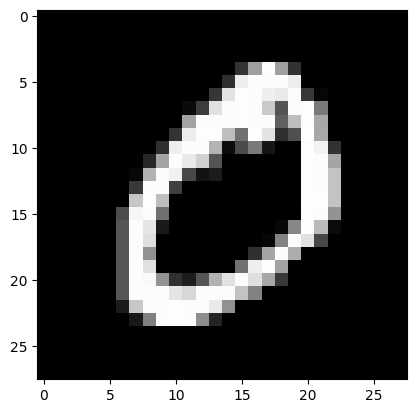

In [28]:
import matplotlib.pyplot as plt
for images,labels in test_dataloader:
    outputs= model(images)

    _,predicted= torch.max(outputs,1)

    for i in range(10):
        
        print(f"Actual:{labels[i].item()} | Predicted: {predicted[i].item()}")
    break




plt.imshow(images[1].squeeze(),cmap='gray')
plt.show()